# 🪐 NIUS (Astronomy) 2025: Data Processing in Astronomy Workshop  
## Session: Time Series Analysis — Catching Shadows of Distant Worlds
---
📅 **Date:** 15 Dec-2025  🧮  

---

### 🎯 Session Objective

Welcome to this tutorial session! In this tutorial, we will learn about one of the most common, powerful, yet simple astrophysical techniques to detect exoplanets around their host star.

We shall explore:
- What light curves are and how to make sense of them
- How to detect tiny dips caused by planetary transits
- How to model these dips using Python tools like `Batman`
- How to find planet and orbital properties through this


---

### 🧠 Pro Tip for Today

> *In astronomy, you often learn a lot from what you **can’t see**... especially when it causes a tiny but regular blip in what you **can**.* 😉

So let’s get ready to work with real telescope data, build up our coding toolkit, and detect planets in their shadows.

Keep your curiosity high and your numpy arrays tidy — we’re just getting started!



**Lecture:**
Dr. Priyanka Chaturvedi, TIFR

**Tutorial:**
Prof. Bhaswati Mookerjea, Dr. Priyanka Chaturvedi,
Dr. Akshat Singhal, Mr. Pritesh Ranadive, Ms. Sai Shetye, Mr. Durgesh Gaikwad, and members of Astronomy Cell, HBCSE-TIFR   <br>


# Transit Light Curve analysis
We shall use a package called Lightkurve to extract light curve from TESS
See https://lightkurve.github.io/lightkurve/ for more information about the Lightkurve package
+  "TESS Full Frame Images (FFIs) to extracted and systematics-corrected light curves for any given star observed by TESS"

#Lightkurve is a Python package that simplifies downloading, visualizing, and analyzing space-based photometric data from missions like Kepler and TESS. It provides easy tools for working with light curves, performing aperture photometry, and exploring transit signals.Because of its simple interface, Lightkurve is widely used for teaching and research in stellar variability and exoplanet studies.


We will load the tess pixel file to avoid internet dependency from MAST portal

In [ ]:
# from google.colab import files
# uploaded = files.upload()
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Upgrade pip first
!pip install --upgrade pip

# Install scientific stack
!pip install numpy==1.26.4 scipy matplotlib

# Install Lightkurve (NASA-supported)
!pip install lightkurve astroquery

# Optional but useful astronomy tools
!pip install batman-package
!pip install PyTransit==2.5.18  # works with numpy 1.26.x
!pip install astropy


  Using cached lightkurve-2.5.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached astroquery-0.4.11-py3-none-any.whl.metadata (6.5 kB)
  Using cached fbpca-1.0.tar.gz (11 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 106.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 127.9 MB/s  0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11428 sha256=07052485a89ef1a32ce682bc39ff7dd1f4f379ff5e4d8342bfecd08f868421e7
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization: filename=memoization-0.4.0-py3-none-any.w

Let us check if our installation was successful

In [ ]:
import numpy as np
import lightkurve as lk
from astroquery.mast import Catalogs
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Lightkurve version:", lk.__version__)


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


NumPy version: 1.26.4
Lightkurve version: 2.5.1


## Get WASP-100's light curve from TESS data

In [ ]:
import lightkurve as lk
from astropy.io import fits

#abs_drive_path = "/content/drive/MyDrive/NIUS-Astro-2025/Workshops/Priyanka+Bhaswati/"
abs_drive_path = "/content/drive/MyDrive/exoplanetnius/"
# --- Paths to your uploaded files ---
tpf_path = abs_drive_path+"tess2018206045859-s0001-0000000038846515-0120-s_tp.fits"
lc_path  = abs_drive_path+"tess2018206045859-s0001-0000000038846515-0120-s_lc.fits"

# --- Load TPF and LC offline ---
tpf = lk.read(tpf_path)
lc  = lk.read(lc_path)

# --- Read metadata directly from FITS header ---
h = fits.getheader(lc_path)

tic = h.get("TICID", "Unknown")
gaia = h.get("GAIAID", "Unknown")
tmag = h.get("TESSMAG", "Unknown")
ra   = h.get("RA_OBJ", "Unknown")
dec  = h.get("DEC_OBJ", "Unknown")

print(f"Loaded TIC {tic} (Gaia {gaia})")
print(f"TESS mag = {tmag}")
print(f"RA, Dec = {ra}, {dec}")
print("Files loaded completely offline.")


Loaded TIC 38846515 (Gaia Unknown)
TESS mag = 10.31569958
RA, Dec = 68.9597092399964, -64.0270368810381
Files loaded completely offline.


/usr/local/lib/python3.12/dist-packages/astropy/utils/decorators.py:620: LightkurveDeprecationWarning: "aperture_mask" was deprecated in version 2.0 and will be removed in a future version. 
  return function(*args, **kwargs)


<Figure size 500x500 with 0 Axes>

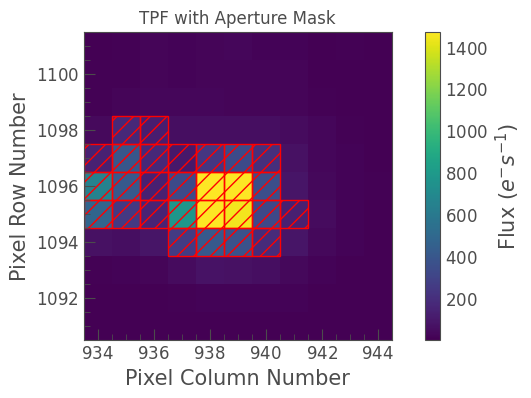

In [ ]:
from lightkurve.correctors import PLDCorrector
import lightkurve as lk

# Load TPF
tpf_path = abs_drive_path+"tess2018206045859-s0001-0000000038846515-0120-s_tp.fits"
tpf = lk.read(tpf_path)

# Create aperture mask
aperture = tpf.create_threshold_mask(threshold=3)

# Extract raw aperture photometry
raw_lc = tpf.to_lightcurve(aperture_mask=aperture)

# Apply PLD correction (Eleanor-like PCA correction)
corrector = PLDCorrector(tpf)
corrected_lc = corrector.correct(aperture_mask=aperture)

# Alias corrected LC as 'data' for compatibility
data = corrected_lc

# Plot the aperture masks

plt.figure(figsize=(5,5))
tpf.plot(aperture_mask=aperture)
plt.title("TPF with Aperture Mask")
plt.show()



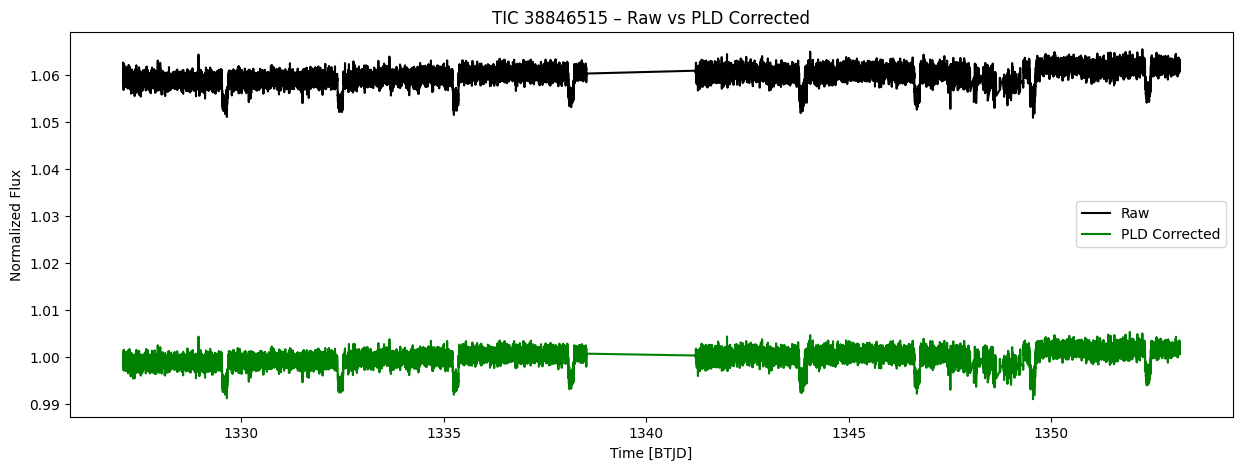

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Quality mask from raw data
q = raw_lc.quality == 0

# Convert Time objects → float BTJD
raw_time = raw_lc.time.value
corr_time = corrected_lc.time.value

# Raw flux
raw_flux = raw_lc.flux
corr_flux = corrected_lc.flux

plt.figure(figsize=(15,5))

# Plot raw flux
plt.plot(
    raw_time[q],
    raw_flux[q] / np.nanmedian(raw_flux[q]) + 0.06,
    'k',
    label="Raw"
)

# Align corrected flux masking
corr_mask = q[:len(corr_flux)]

plt.plot(
    corr_time[corr_mask],
    corr_flux[corr_mask] / np.nanmedian(corr_flux[corr_mask]),
    'g',
    label="PLD Corrected"
)

plt.ylabel("Normalized Flux")
plt.xlabel("Time [BTJD]")
plt.title("TIC 38846515 – Raw vs PLD Corrected")
plt.legend()
plt.show()



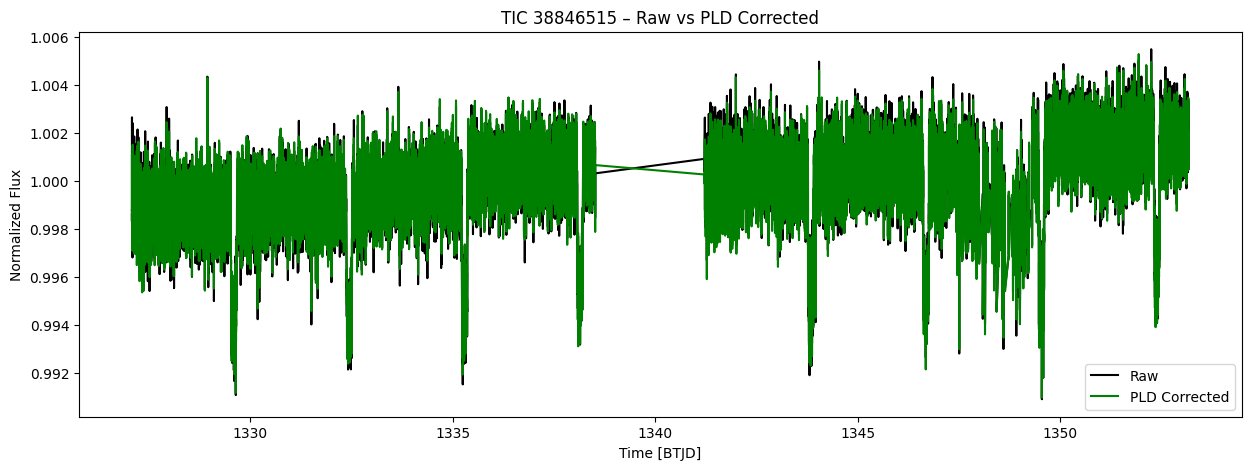

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Quality mask from raw data
q = raw_lc.quality == 0

# Convert Time objects → float BTJD
raw_time = raw_lc.time.value
corr_time = corrected_lc.time.value

# Raw flux
raw_flux = raw_lc.flux
corr_flux = corrected_lc.flux

plt.figure(figsize=(15,5))

# Plot raw flux
plt.plot(
    raw_time[q],
    raw_flux[q] / np.nanmedian(raw_flux[q]),
    'k',
    label="Raw"
)

# Align corrected flux masking
corr_mask = q[:len(corr_flux)]

plt.plot(
    corr_time[corr_mask],
    corr_flux[corr_mask] / np.nanmedian(corr_flux[corr_mask]),
    'g',
    label="PLD Corrected"
)

plt.ylabel("Normalized Flux")
plt.xlabel("Time [BTJD]")
plt.title("TIC 38846515 – Raw vs PLD Corrected")
plt.legend()
plt.show()

## BoxLeastSquares to find period and transists
+ See https://docs.astropy.org/en/latest/timeseries/bls.html on BLS

The Box Least Squares (BLS) method is one of the most widely used techniques for detecting transiting exoplanets in space-based photometry (Kepler, K2, TESS).
Unlike sinusoidal signals, transits have a box-shaped dip: flat → sudden drop → flat → return to baseline.

BLS is designed specifically to find periodic, box-shaped decreases in brightness.

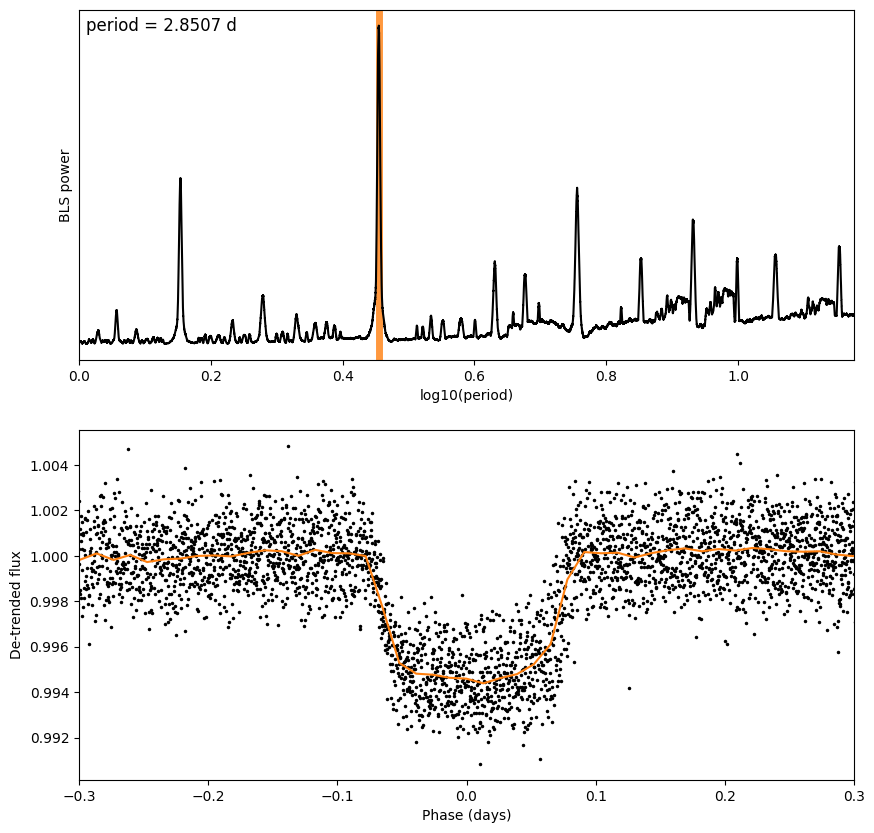

In [ ]:
import numpy as np
from astropy.timeseries import BoxLeastSquares
import matplotlib.pyplot as plt

# ---- Mask using raw quality but truncate to correct length ----
q_raw = raw_lc.quality == 0
corr_mask = q_raw[:len(corrected_lc.time)]

# ---- Convert Time objects to float BTJD ----
try:
    time = corrected_lc.time[corr_mask].value       # if Time has .value
except AttributeError:
    time = corrected_lc.time[corr_mask]             # already numpy

# ---- Convert Flux to plain numpy floats ----
try:
    flux = corrected_lc.flux[corr_mask].value
except AttributeError:
    flux = corrected_lc.flux[corr_mask]


# ---- Period Grid ----
period_grid = np.exp(np.linspace(np.log(1), np.log(15), 50000))

# ---- BLS ----
bls = BoxLeastSquares(time, flux)
bls_power = bls.power(period_grid, 0.1, oversample=20)

# ---- Best peak ----
index = np.argmax(bls_power.power)
bls_period = bls_power.period[index]
bls_t0 = bls_power.transit_time[index]
bls_depth = bls_power.depth[index]

# ---- Transit mask ----
transit_mask = bls.transit_mask(time, bls_period, 0.2, bls_t0)

# ---- Plotting ----
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Periodogram
ax = axes[0]
ax.axvline(np.log10(bls_period), color="C1", lw=5, alpha=0.8)
ax.plot(np.log10(bls_power.period), bls_power.power, "k")
ax.annotate(f"period = {bls_period:.4f} d",
            (0, 1), xycoords="axes fraction",
            xytext=(5, -5), textcoords="offset points",
            va="top", ha="left", fontsize=12)
ax.set_ylabel("BLS power")
ax.set_yticks([])
ax.set_xlim(np.log10(period_grid.min()), np.log10(period_grid.max()))
ax.set_xlabel("log10(period)")

# 2. Folded Transit
ax = axes[1]
x_fold = (time - bls_t0 + 0.5*bls_period) % bls_period - 0.5*bls_period
m = np.abs(x_fold) < 0.4

bins = np.linspace(-0.41, 0.41, 64)
denom, _ = np.histogram(x_fold, bins)
num, _ = np.histogram(x_fold, bins, weights=flux)
denom[num == 0] = 1.0

ax.plot(x_fold[m], flux[m] / np.median(num/denom), ".k", ms=3)
ax.plot(0.5*(bins[1:] + bins[:-1]),
        (num / denom) / np.median(num/denom),
        color="C1")

ax.set_xlim(-0.3, 0.3)
ax.set_ylabel("De-trended flux")
ax.set_xlabel("Phase (days)")
plt.show()


2nd strongest period = 1.4253 d


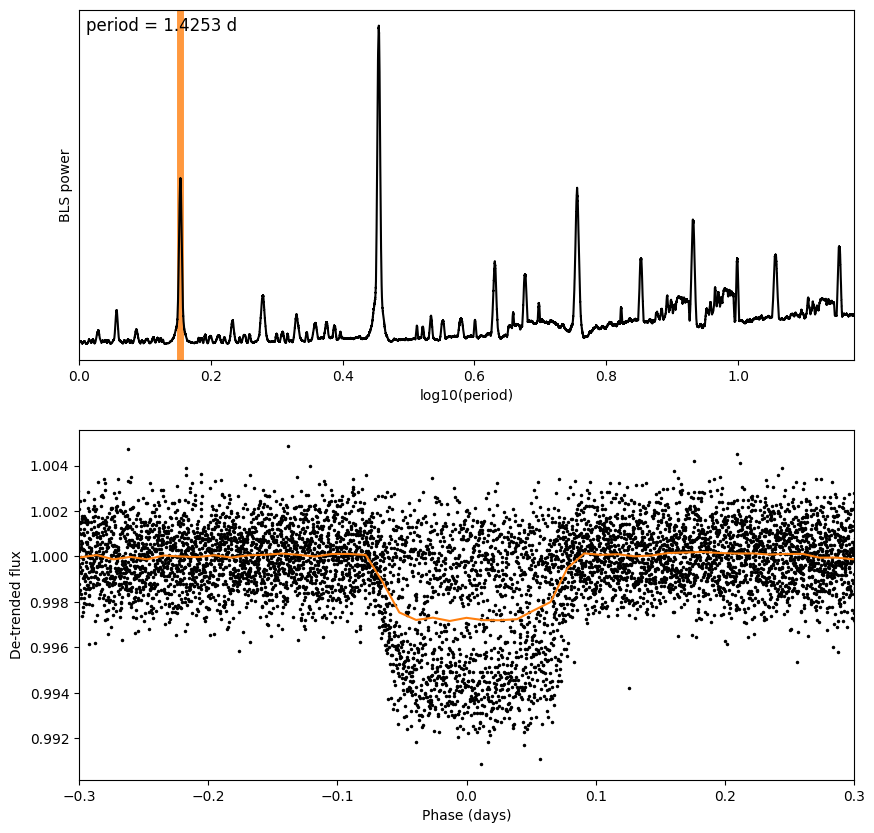

In [ ]:
import numpy as np
from astropy.timeseries import BoxLeastSquares
import matplotlib.pyplot as plt

# ---- Mask using raw quality but truncate to correct length ----
q_raw = raw_lc.quality == 0
corr_mask = q_raw[:len(corrected_lc.time)]

# ---- Convert Time objects to float BTJD ----
try:
    time = corrected_lc.time[corr_mask].value       # if Time has .value
except AttributeError:
    time = corrected_lc.time[corr_mask]             # already numpy

# ---- Convert Flux to plain numpy floats ----
try:
    flux = corrected_lc.flux[corr_mask].value
except AttributeError:
    flux = corrected_lc.flux[corr_mask]


# ---- Period Grid ----
period_grid = np.exp(np.linspace(np.log(1), np.log(15), 50000))

# ---- BLS ----
bls = BoxLeastSquares(time, flux)
bls_power = bls.power(period_grid, 0.1, oversample=20)

# ---- Best peak ----
#index = np.argmax(bls_power.power)
#bls_period = bls_power.period[index]
#bls_t0 = bls_power.transit_time[index]
#bls_depth = bls_power.depth[index]

# Sort indices by descending power
sorted_idx = np.argsort(bls_power.power)[::-1]

# First is best
best_idx = sorted_idx[0]

# Find next that is sufficiently far away
for i in sorted_idx[1:]:
    if abs(bls_power.period[i] - bls_period) > 0.05 * bls_period:
        second_idx = i
        break

second_period = bls_power.period[second_idx]
print(f"2nd strongest period = {second_period:.4f} d")


# ---- Transit mask ----
transit_mask = bls.transit_mask(time, second_period, 0.2, bls_t0)

# ---- Plotting ----
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Periodogram
ax = axes[0]
ax.axvline(np.log10(second_period), color="C1", lw=5, alpha=0.8)
ax.plot(np.log10(bls_power.period), bls_power.power, "k")
ax.annotate(f"period = {second_period:.4f} d",
            (0, 1), xycoords="axes fraction",
            xytext=(5, -5), textcoords="offset points",
            va="top", ha="left", fontsize=12)
ax.set_ylabel("BLS power")
ax.set_yticks([])
ax.set_xlim(np.log10(period_grid.min()), np.log10(period_grid.max()))
ax.set_xlabel("log10(period)")

# 2. Folded Transit
ax = axes[1]
x_fold = (time - bls_t0 + 0.5*second_period) % second_period - 0.5*second_period
m = np.abs(x_fold) < 0.4

bins = np.linspace(-0.41, 0.41, 64)
denom, _ = np.histogram(x_fold, bins)
num, _ = np.histogram(x_fold, bins, weights=flux)
denom[num == 0] = 1.0

ax.plot(x_fold[m], flux[m] / np.median(num/denom), ".k", ms=3)
ax.plot(0.5*(bins[1:] + bins[:-1]),
        (num / denom) / np.median(num/denom),
        color="C1")

ax.set_xlim(-0.3, 0.3)
ax.set_ylabel("De-trended flux")
ax.set_xlabel("Phase (days)")
plt.show()


## Let's create some artifical tranist light curves first

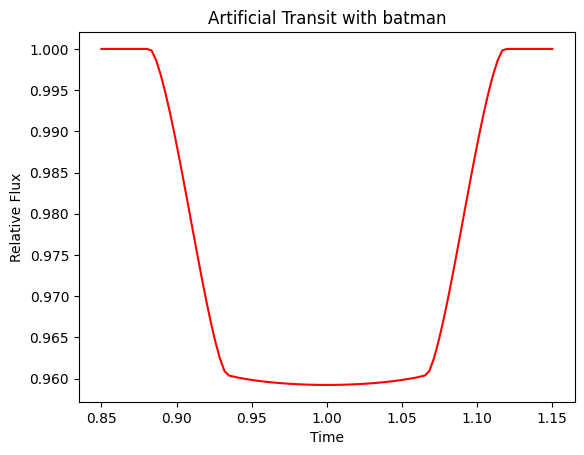

In [ ]:
import batman
import numpy as np
import matplotlib.pyplot as plt

times = np.linspace(0.85, 1.15, 100)

params = batman.TransitParams()

params.t0  = 1.0       # mid-transit time
params.per = 2.1       # orbital period
params.rp  = 0.2       # Rp/R*
params.a   = 3.2       # semi-major axis scaled by stellar radius
params.inc = np.degrees(0.45 * np.pi)   # convert rad → degrees

params.ecc = 0.0       # eccentricity
params.w   = 0.0       # argument of periastron

# Limb darkening coefficients
params.u = [0.1, 0.0]
params.limb_dark = "quadratic"

# --- Generate the model ---
m = batman.TransitModel(params, times)
flux = m.light_curve(params)

# --- Plot ---
plt.plot(times, flux, "r-")
plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("Artificial Transit with batman")
plt.show()


## Explore various parameter tweaks and its impact on the light curve

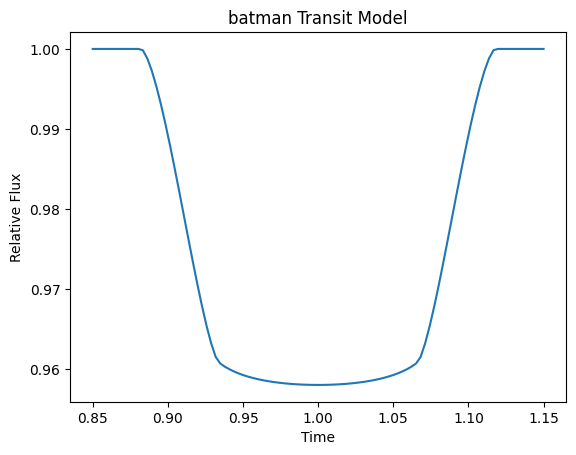

In [ ]:
# Play around by varying these parameters to see what changes and how.

k  = 0.2          # planet-to-star radius ratio
ldc = [0.1, 0.2]  # limb darkening coefficients (quadratic)
t0 = 1.0          # mid-transit time
p  = 2.1          # orbital period (days)
a  = 3.2          # semi-major axis scaled by stellar radius
i  = 0.45 * np.pi # inclination in radians
e  = 0.0          # eccentricity
w  = 0.0          # argument of periastron

# ---- Set parameters in batman ----
params = batman.TransitParams()
params.t0  = t0
params.per = p
params.rp  = k
params.a   = a
params.inc = np.degrees(i)  # batman requires degrees

params.ecc = e
params.w   = w

params.u = ldc
params.limb_dark = "quadratic"

# ---- Generate model ----
model = batman.TransitModel(params, times)
flux = model.light_curve(params)

plt.plot(times, flux)
plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("batman Transit Model")
plt.show()


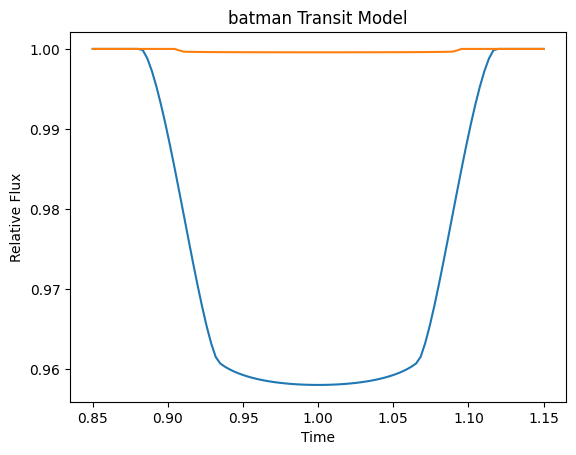

In [ ]:
# Play around by varying these parameters to see what changes and how.

k1  = 0.2
k2=0.02          # planet-to-star radius ratio
ldc = [0.1, 0.2]  # limb darkening coefficients (quadratic)
t0 = 1.0          # mid-transit time
p  = 2.1          # orbital period (days)
a  = 3.2          # semi-major axis scaled by stellar radius
i  = 0.45 * np.pi # inclination in radians
e  = 0.0          # eccentricity
w  = 0.0          # argument of periastron




# ---- Set parameters in batman ----
params = batman.TransitParams()
params.t0  = t0
params.per = p
params.rp  = k1
params.a   = a
params.inc = np.degrees(i)  # batman requires degrees

params.ecc = e
params.w   = w

params.u = ldc
params.limb_dark = "quadratic"

# ---- Generate model ----
model = batman.TransitModel(params, times)
flux = model.light_curve(params)

plt.plot(times, flux)

arams = batman.TransitParams()
params.t0  = t0
params.per = p
params.rp  = k2
params.a   = a
params.inc = np.degrees(i)  # batman requires degrees

params.ecc = e
params.w   = w

params.u = ldc
params.limb_dark = "quadratic"

# ---- Generate model ----
model = batman.TransitModel(params, times)
flux = model.light_curve(params)

plt.plot(times, flux)
plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("batman Transit Model")
plt.show()


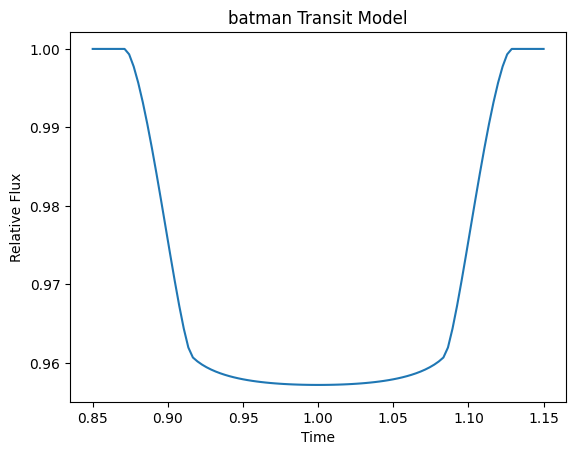

In [ ]:
# Play around by varying these parameters to see what changes and how.

k  = 0.2          # planet-to-star radius ratio
ldc = [0.1, 0.2]  # limb darkening coefficients (quadratic)
t0 = 1.0          # mid-transit time
p  = 2.1          # orbital period (days)
a  = 3.2          # semi-major axis scaled by stellar radius
i  = 91 # inclination in radians
e  = 0        # eccentricity
w  = 0.0          # argument of periastron

# ---- Set parameters in batman ----
params = batman.TransitParams()
params.t0  = t0
params.per = p
params.rp  = k
params.a   = a

params.inc = i  # batman requires degrees

params.ecc = e
params.w   = w

params.u = ldc
params.limb_dark = "quadratic"

# ---- Generate model ----
model = batman.TransitModel(params, times)
flux = model.light_curve(params)

plt.plot(times, flux)
plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("batman Transit Model")
plt.show()


Lengths: 15882 15882 15882
==== Transit Fit Results ====
Rp/R*   = 0.0727
a/R*    = 4.26
inc     = 79.37 deg
t0      = 0.00369 days


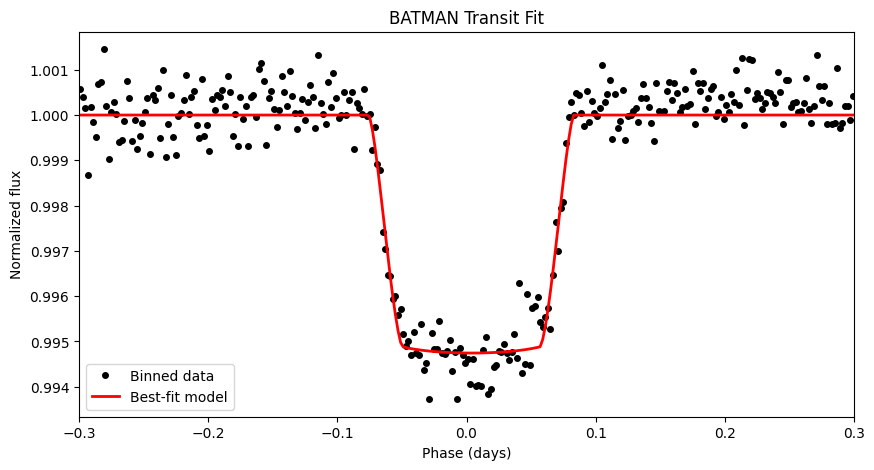

In [ ]:
# ============================================================
#   CLEAN BATMAN TRANSIT FIT (using binned folded TESS light curve)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import batman
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# STEP 1 — Recompute folded time (x_fold) and normalized flux (y_flux)
#          Ensures both arrays have the SAME length
# ------------------------------------------------------------

# Corrected time & flux from previous BLS block
time = corrected_lc.time[corr_mask].value     # float BTJD
flux = corrected_lc.flux[corr_mask]           # numpy array

# Fold using BLS period and t0
x_fold = (time - bls_t0 + 0.5*bls_period) % bls_period - 0.5*bls_period

# Normalize flux
y_flux = flux / np.median(flux)

print("Lengths:", len(time), len(x_fold), len(y_flux))  # sanity check

# ------------------------------------------------------------
# STEP 2 — Manual binning for smoother model fitting
# ------------------------------------------------------------

bin_width = 0.002
bins = np.arange(-0.3, 0.3 + bin_width, bin_width)
t_centers = 0.5 * (bins[1:] + bins[:-1])

t_binned = []
f_binned = []

for i in range(len(bins)-1):
    m = (x_fold >= bins[i]) & (x_fold < bins[i+1])
    if np.any(m):
        t_binned.append(t_centers[i])
        f_binned.append(np.median(y_flux[m]))

t_fit = np.array(t_binned)
f_fit = np.array(f_binned)

# Sort for stability
order = np.argsort(t_fit)
t_fit = t_fit[order]
f_fit = f_fit[order]

# ------------------------------------------------------------
# STEP 3 — Define transit model (BATMAN)
# ------------------------------------------------------------

def transit_model(t, k, a, inc_deg, t0):
    params = batman.TransitParams()
    params.t0  = t0
    params.per = bls_period      # fixed from BLS
    params.rp  = k               # Rp/R*
    params.a   = a               # a/R*
    params.inc = inc_deg         # degrees
    params.ecc = 0.0
    params.w   = 0.0
    params.limb_dark = "quadratic"
    params.u = [0.1, 0.0]        # fixed LDCs

    m = batman.TransitModel(params, t)
    return m.light_curve(params)

# ------------------------------------------------------------
# STEP 4 — Fit using curve_fit
# ------------------------------------------------------------

p0 = [0.1, 10.0, 87.0, 0.0]       # initial guesses for [k, a/R*, inc, t0]

bounds_lower = [0.01,  2, 60, -0.05]
bounds_upper = [0.50, 30, 90,  0.05]

popt, pcov = curve_fit(
    transit_model,
    t_fit,
    f_fit,
    p0=p0,
    bounds=(bounds_lower, bounds_upper),
    maxfev=20000
)

k_fit, a_fit, inc_fit, t0_fit = popt

print("==== Transit Fit Results ====")
print(f"Rp/R*   = {k_fit:.4f}")
print(f"a/R*    = {a_fit:.2f}")
print(f"inc     = {inc_fit:.2f} deg")
print(f"t0      = {t0_fit:.5f} days")

# ------------------------------------------------------------
# STEP 5 — Plot results
# ------------------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(t_fit, f_fit, 'ko', ms=4, label="Binned data")
plt.plot(t_fit, transit_model(t_fit, *popt), 'r-', lw=2, label="Best-fit model")

plt.xlabel("Phase (days)")
plt.ylabel("Normalized flux")
plt.title("BATMAN Transit Fit")
plt.xlim(-0.3, 0.3)
plt.legend()
plt.show()


,11,81,

,11,81

## MCMC Markov Chain Monte Carlo
It is a statistical technique used to sample the probability distribution of model parameters.
Instead of giving you just one best-fit value, MCMC explores the entire space of possible solutions that fit the data.

100%|██████████| 3000/3000 [00:07<00:00, 385.32it/s]


====== MCMC RESULTS ======
k       = 0.0707 (Rp/R*)
a/R*    = 2.36
inc     = 84.87 deg
t0      = 0.00349 phase


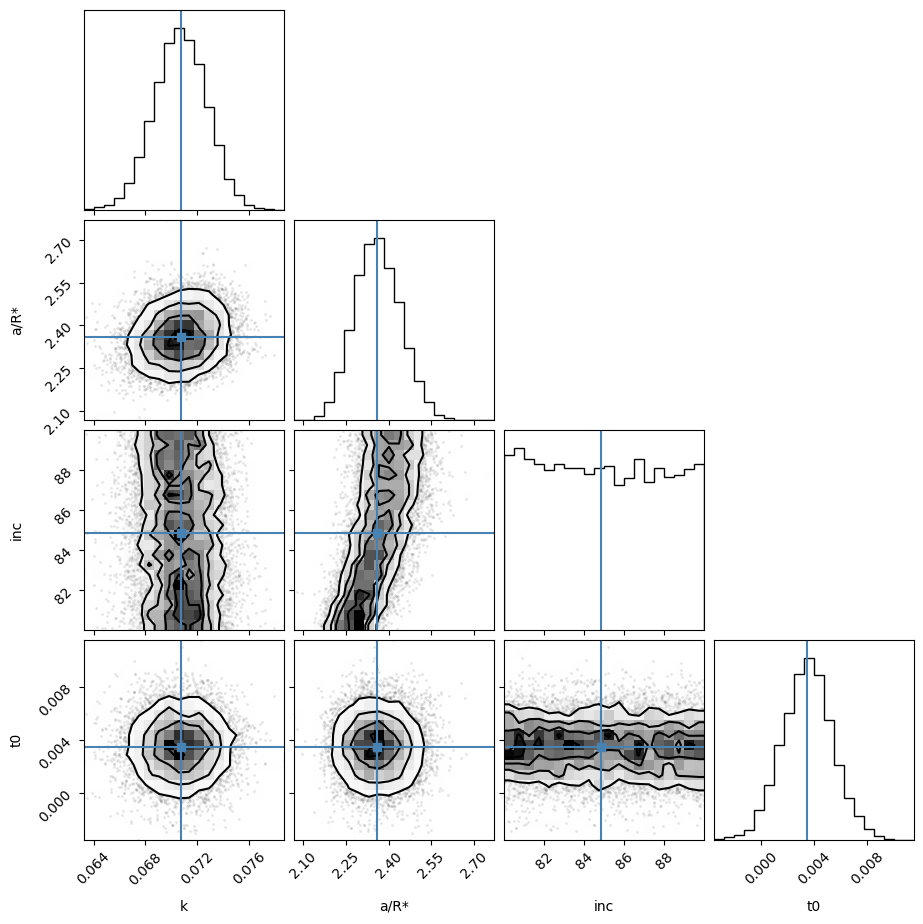

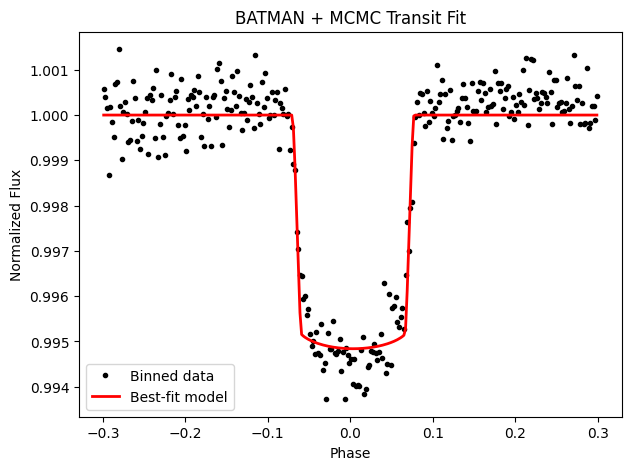

In [ ]:
!pip install emcee corner batman-package --quiet

import numpy as np
import emcee, batman, corner
import matplotlib.pyplot as plt

# ============================================================
# 1. Transit model in PHASE space
# ============================================================
def transit_model(theta, t):
    k, a, inc, t0 = theta   # unpack parameters

    params = batman.TransitParams()
    params.t0 = t0
    params.per = 1.0                # normalized period (phase)
    params.rp = k
    params.a = a
    params.inc = inc
    params.ecc = 0.0
    params.w = 0.0
    params.u = [0.1, 0.0]           # limb-darkening
    params.limb_dark = "quadratic"

    model = batman.TransitModel(params, t)
    return model.light_curve(params)


# ============================================================
# 2. Log-posterior = prior + likelihood
# ============================================================
def log_prior(theta):
    k, a, inc, t0 = theta
    if 0.01 < k < 0.3 and 2 < a < 30 and 80 < inc < 90 and -0.05 < t0 < 0.05:
        return 0.0
    return -np.inf

def log_likelihood(theta, t, f, sigma):
    model = transit_model(theta, t)
    return -0.5 * np.sum(((f - model) / sigma)**2)

def log_prob(theta, t, f, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, f, sigma)


# ============================================================
# 3. Data: binned folded light curve (already prepared earlier)
# ============================================================
t = t_fit          # phase
f = f_fit          # flux
sigma = np.std(f) * np.ones_like(f)


# ============================================================
# 4. Initial guess for sampler
# ============================================================
depth_est = 1 - np.min(f)
k0 = np.sqrt(depth_est)   # Rp/R*
initial = np.array([k0, 8.0, 87.0, 0.0])


# ============================================================
# 5. Run MCMC with emcee
# ============================================================
ndim, nwalkers = 4, 32
p0 = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(t, f, sigma))
sampler.run_mcmc(p0, 3000, progress=True)

samples = sampler.get_chain(discard=500, thin=10, flat=True)

k_m, a_m, inc_m, t0_m = np.median(samples, axis=0)

print("====== MCMC RESULTS ======")
print(f"k       = {k_m:.4f} (Rp/R*)")
print(f"a/R*    = {a_m:.2f}")
print(f"inc     = {inc_m:.2f} deg")
print(f"t0      = {t0_m:.5f} phase")


# ============================================================
# 6. Corner plot of posteriors
# ============================================================
corner.corner(
    samples,
    labels=["k", "a/R*", "inc", "t0"],
    truths=[k_m, a_m, inc_m, t0_m]
)
plt.show()


# ============================================================
# 7. Plot best-fit transit model
# ============================================================
plt.figure(figsize=(7,5))
plt.plot(t, f, ".k", label="Binned data")
plt.plot(t, transit_model([k_m, a_m, inc_m, t0_m], t),
         "r-", lw=2, label="Best-fit model")
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.legend()
plt.title("BATMAN + MCMC Transit Fit")
plt.show()


## End of the day

# Problem statement:
## Find everything you can from the following data:

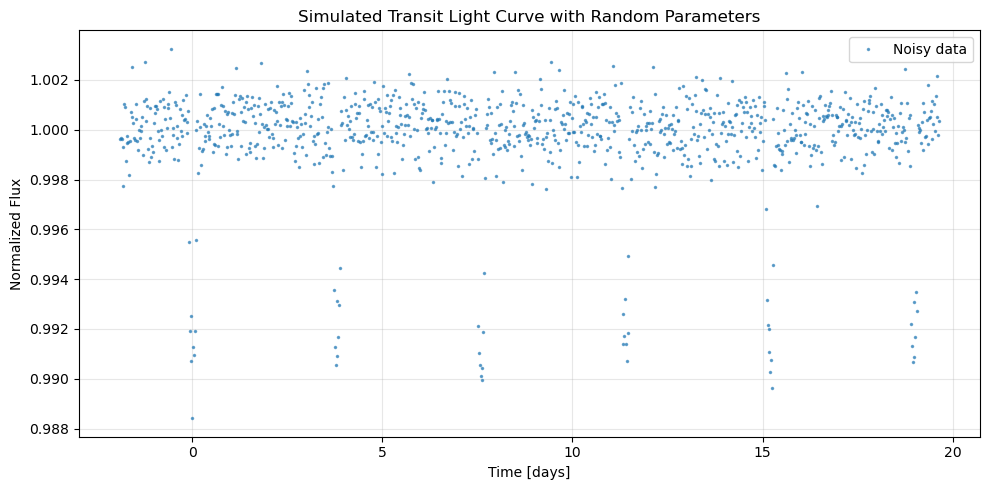

In [ ]:
# --- Random physically valid parameters ---
np.random.seed(42)  # for reproducibility

k = np.random.uniform(0.05, 0.15)                 # planet/star radius ratio
ldc = list(np.random.uniform(0.1, 0.4, size=2))   # limb darkening coefficients
t0 = 0.0                                          # transit center (BJD - reference)
p = np.random.uniform(2.0, 5.0)                   # orbital period in days
a = np.random.uniform(5.0, 15.0)                  # semi-major axis in stellar radii

# Ensure inclination gives transit: cos(i) < (1 + k) / a
cosi_max = (1 + k) / a
i = np.arccos(np.random.uniform(0, cosi_max))     # inclination in radians

e = 0.0                                           # eccentricity
w = 0.0                                           # argument of periastron

# --- Generate time array over 5 transits ---
n_cycles = np.random.uniform(5,8)
times = np.linspace(t0 - 0.5*p, t0 + n_cycles*p, 1000)

# --- Generate model flux ---
tm = QuadraticModel()
tm.set_data(times)
true_flux = tm.evaluate(k, ldc, t0, p, a, i, e, w)

# --- Add Gaussian noise ---
noise_mean = np.random.uniform(-0.0002, 0.0002)
noise_std = np.random.uniform(0.0005, 0.0012)
noisy_flux = true_flux + np.random.normal(noise_mean, noise_std, size=true_flux.shape)

# --- Plot the result ---
plt.figure(figsize=(10, 5))
plt.plot(times, noisy_flux, '.', ms=3, alpha=0.6, label='Noisy data')
#plt.plot(times, true_flux, 'r-', lw=2, label='True model')
plt.xlabel("Time [days]")
plt.ylabel("Normalized Flux")
plt.title("Simulated Transit Light Curve with Random Parameters")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
